# MH-Weed16: YOLO26 Object Detection, Multi-Modal Feature Extraction, and Agronomic Vision Pipeline

This notebook provides an end-to-end computer vision and agricultural analytics pipeline for multi-class weed detection, multi-modal feature vector extraction, two-phase accelerated model training, and edge inference on the MH-Weed16 dataset using Ultralytics YOLO26.

### Dataset Overview and Reference
The **MH-Weed16** dataset is a precision agriculture benchmark collected from soybean fields across Maharashtra, India, during the monsoon and post-monsoon cropping seasons (July - November 2023). Imagery was captured under natural outdoor illumination at high resolution (1920x1080) using an Intel RealSense Depth camera.

- **Kaggle Dataset**: [MH-Weed16 on Kaggle](https://www.kaggle.com/datasets/sayalis069/mh-weed16)
- **Mendeley Data Repository**: [MH-Weed16 on Mendeley Data](https://data.mendeley.com/datasets/29yxd5vj6p/1)
- **Target Weed Species (15 Classes in YOLO Darknet Subset)**:
  1. *Commelina benghalensis* (kena)
  2. *Cyperus rotundus* (lavhala)
  3. *Chenopodium album* (lambs_quarters)
  4. *Malva parviflora* (little_mallow)
  5. *Euphorbia hirta* (moti_dudhi)
  6. *Ipomoea obscura* (obscure_morning_glory)
  7. *Clitoria ternatea* (asian_pigeonwings)
  8. *Parthenium hysterophorus* (bilayat)
  9. *Euphorbia thymifolia* (choti_dudhi)
  10. *Digitaria sanguinalis* (digitaria)
  11. *Parthenium hysterophorus* (gajar_gavat)
  12. *Euphorbia indica* (graceful_sandmat)
  13. *Senna obtusifolia* (sicklepod)
  14. *Cynodon dactylon* (harali)
  15. *Chamaecrista pumila* (dwarf_cassia)

### Pipeline Architecture:
1. Environment Setup and Hardware Diagnostic
2. Zero-Duplication Dataset Partitioning and Directory Configuration
3. Exploratory Data Analysis (EDA) and Label Integrity Audit
4. Multi-Modal Feature Vector Engineering and Spectral Indices
5. Feature Vector Extraction, Assembly, and Persistent Storage
6. Principal Component Analysis (PCA) and Dimensionality Reduction
7. Outlier Detection and Anomaly Auditing (Isolation Forest)
8. Deep Latent Feature Vector Extraction (YOLO26 Embeddings & Similarity Search)
9. Bounding Box Anchor Geometry Analysis (K-Means)
10. Agricultural Image Contrast Enhancement (CLAHE and ExG)
11. Architectural Customization, Layer Ablation Suite, and Edge ONNX Optimization
12. Genetic Algorithm Hyperparameter Evolution (Optional model.tune)
13. Hyperparameter Visual Analytics Suite
14. Two-Phase Accelerated YOLO26n Model Training (Frozen Backbone & Fine-Tuning)
15. Model Evaluation on Held-Out Test Set
16. Inference, SAHI Sliced Prediction, and Edge Export

## 1. Environment Setup and Hardware Diagnostic
Configure the runtime environment, initialize random seeds across Python, NumPy, and PyTorch for deterministic execution, and diagnose available hardware accelerators (Intel Arc Graphics via PyTorch XPU, NVIDIA CUDA, Apple Silicon MPS, or CPU fallback).

In [1]:
import os
import sys
import time
import glob
import math
import random
import shutil
import pathlib
import subprocess
import concurrent.futures
from collections import Counter
from tqdm.auto import tqdm

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import yaml

import torch
import torchvision
import ultralytics
from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Seed initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT_DIR = pathlib.Path(".").resolve()

# Compute device detection
if hasattr(torch, 'xpu') and torch.xpu.is_available():
    device = 'xpu'
    device_name = torch.xpu.get_device_name(0)
elif torch.cuda.is_available():
    device = 'cuda'
    device_name = torch.cuda.get_device_name(0)
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
    device_name = 'Apple Silicon MPS'
else:
    device = 'cpu'
    device_name = 'CPU'

print("=" * 65)
print(f"Working Directory:   {ROOT_DIR}")
print(f"PyTorch Version:     {torch.__version__}")
print(f"Ultralytics Version: {ultralytics.__version__}")
print(f"Compute Device:      {device} ({device_name})")
print("=" * 65)

Working Directory:   D:\proj\MHWeed16\mhweedaiml
PyTorch Version:     2.14.1+xpu
Ultralytics Version: 8.4.150
Compute Device:      xpu (Intel(R) Arc(TM) Graphics)


## 2. Zero-Duplication Dataset Partitioning and Directory Configuration
The MH-Weed16 dataset contains 6,656 raw captures (over 4 GB). To avoid redundant file duplication on disk, we link directories using symbolic NTFS directory junctions on Windows (`cmd /c mklink /J`) or POSIX symlinks.

We then create reproducible index splits (`train.txt` at 80%, `val.txt` at 10%, `test.txt` at 10%) and generate the dataset definition YAML (`mhweed16.yaml`) required by Ultralytics YOLO26.

In [2]:
RAW_IMAGES = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Clicks" / "intel Real Sense Depth_Clicks"
RAW_LABELS = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Annotations" / "intel Real Sense Depth_Annotations" / "YOLO_darknet"

IMAGES_DIR = ROOT_DIR / "images"
LABELS_DIR = ROOT_DIR / "labels"
ANN_DIR = ROOT_DIR / "annotations"

# Create symbolic junctions if they do not exist
if not IMAGES_DIR.exists() and RAW_IMAGES.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{IMAGES_DIR}" "{RAW_IMAGES}"', shell=True, capture_output=True)
    else:
        IMAGES_DIR.symlink_to(RAW_IMAGES)

if not LABELS_DIR.exists() and RAW_LABELS.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{LABELS_DIR}" "{RAW_LABELS}"', shell=True, capture_output=True)
    else:
        LABELS_DIR.symlink_to(RAW_LABELS)

# Keep annotations alias synced
if not ANN_DIR.exists() and LABELS_DIR.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{ANN_DIR}" "{LABELS_DIR}"', shell=True, capture_output=True)
    else:
        ANN_DIR.symlink_to(LABELS_DIR)

raw_image_files = sorted([p for p in IMAGES_DIR.glob('*.*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
print(f"Raw images discovered: {len(raw_image_files):,}")

Raw images discovered: 6,656


### Dataset Split Generation and Class Mapping
We partition the discovered images into reproducible 80/10/10 splits. We define the 15 botanical weed classes and generate `mhweed16.yaml` with absolute paths for Ultralytics YOLO.

In [3]:
# 80 / 10 / 10 Train / Val / Test Partitioning on whole image files
shuffled_images = list(raw_image_files)
random.seed(SEED)
random.shuffle(shuffled_images)

n_total = len(shuffled_images)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_paths = [os.path.normpath(str(p)) for p in shuffled_images[:n_train]]
val_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train:n_train + n_val]]
test_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train + n_val:]]

def write_split_file(filepath, paths):
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write('\n'.join(paths) + '\n')

write_split_file(ROOT_DIR / "train.txt", train_paths)
write_split_file(ROOT_DIR / "val.txt", val_paths)
write_split_file(ROOT_DIR / "test.txt", test_paths)

print(f"Splits saved: Train={len(train_paths):,} | Val={len(val_paths):,} | Test={len(test_paths):,}")

# Botanical weed species definitions
CLASS_NAMES = {
    0: "kena",
    1: "lavhala",
    2: "lambs_quarters",
    3: "little_mallow",
    4: "moti_dudhi",
    5: "obscure_morning_glory",
    6: "asian_pigeonwings",
    7: "bilayat",
    8: "choti_dudhi",
    9: "digitaria",
    10: "gajar_gavat",
    11: "graceful_sandmat",
    12: "sicklepod",
    13: "harali",
    14: "dwarf_cassia"
}

yaml_content = {
    'path': str(ROOT_DIR).replace('\\', '/'),
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': CLASS_NAMES
}

yaml_file = ROOT_DIR / "mhweed16.yaml"
with open(yaml_file, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"Generated dataset YAML: {yaml_file}")

Splits saved: Train=5,324 | Val=665 | Test=667
Generated dataset YAML: D:\proj\MHWeed16\mhweedaiml\mhweed16.yaml


## 3. Exploratory Data Analysis and Label Integrity Audit
Before training object detectors, we audit the annotation files to verify bounding box coordinate boundaries, detect empty or corrupt label files, and quantify class imbalance across the 15 weed species. Bounding boxes are normalized relative to image dimensions: $(x_c, y_c, w, h) \in [0.0, 1.0]$.

In [4]:
# Parse all annotations and check integrity
ann_files = sorted(list(LABELS_DIR.glob('*.txt')))
box_records = []
corrupt_files = []
out_of_bounds = 0

for ann_path in tqdm(ann_files, desc="Auditing label annotations"):
    try:
        with open(ann_path, 'r', encoding='utf-8') as f:
            lines = [l.strip().split() for l in f if l.strip()]
        for parts in lines:
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            if not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0 and 0.0 < bw <= 1.0 and 0.0 < bh <= 1.0):
                out_of_bounds += 1
            box_records.append({
                'image': ann_path.stem,
                'class_id': cls_id,
                'species': CLASS_NAMES.get(cls_id, f"weed_{cls_id}"),
                'xc': xc,
                'yc': yc,
                'width': bw,
                'height': bh,
                'area': bw * bh,
                'aspect_ratio': bw / max(bh, 1e-6)
            })
    except Exception as e:
        corrupt_files.append((ann_path.name, str(e)))

df_boxes = pd.DataFrame(box_records)
print(f"Total Annotation Files: {len(ann_files):,}")
print(f"Total Bounding Boxes:   {len(df_boxes):,}")
print(f"Corrupt Files:          {len(corrupt_files)}")
print(f"Out of Bounds Boxes:    {out_of_bounds}")

Auditing label annotations:   0%|          | 0/6656 [00:00<?, ?it/s]

Total Annotation Files: 6,656
Total Bounding Boxes:   62,052
Corrupt Files:          0
Out of Bounds Boxes:    12


### Annotation Distribution and Geometry Analysis
We visualize the frequency distribution of each weed species alongside bounding box area and aspect ratio ($W / H$). Figure sizes and typography are scaled cleanly for notebook inspection.

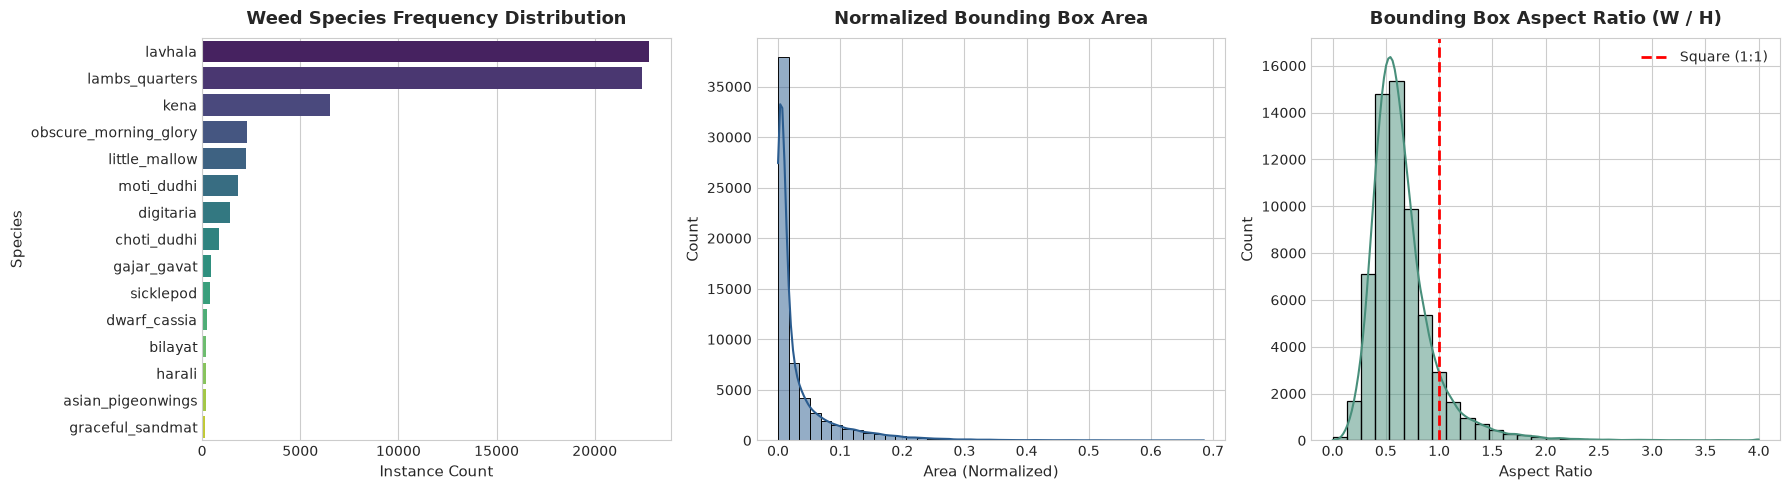

In [5]:
# Plot class distribution and bounding box geometry side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
species_counts = df_boxes['species'].value_counts()
sns.barplot(
    x=species_counts.values, 
    y=species_counts.index, 
    hue=species_counts.index, 
    legend=False, 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title("Weed Species Frequency Distribution", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Instance Count", fontsize=11)
axes[0].set_ylabel("Species", fontsize=11)
axes[0].tick_params(axis='both', which='major', labelsize=10)

# 2. Bounding box area distribution
sns.histplot(df_boxes['area'], bins=40, kde=True, ax=axes[1], color='#2b5c8f')
axes[1].set_title("Normalized Bounding Box Area", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Area (Normalized)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].tick_params(axis='both', which='major', labelsize=10)

# 3. Aspect ratio distribution
sns.histplot(df_boxes['aspect_ratio'].clip(0, 4), kde=True, ax=axes[2], color='#488f7b', bins=30)
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=2.0, label='Square (1:1)')
axes[2].set_title("Bounding Box Aspect Ratio (W / H)", fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel("Aspect Ratio", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)
axes[2].tick_params(axis='both', which='major', labelsize=10)
axes[2].legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

### Ground Truth Verification
Overlay bounding boxes and class tags onto raw field captures to visually inspect label alignment.

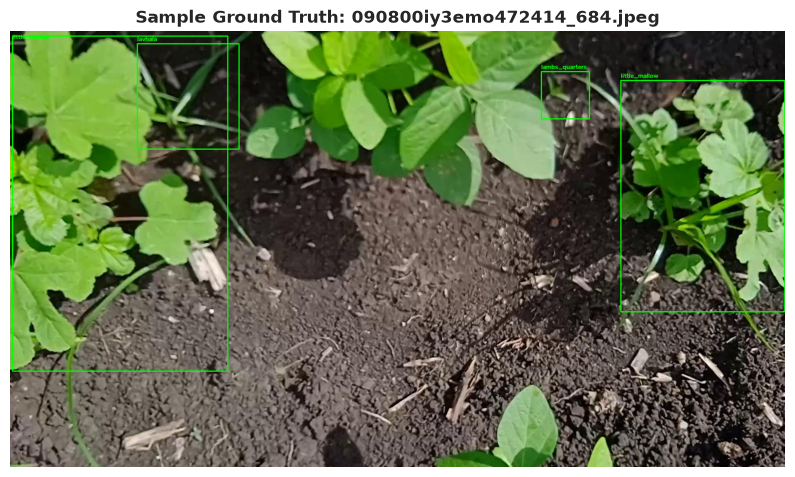

In [6]:
def show_sample_ground_truth(img_path, ann_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return
    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = int((xc - bw / 2.0) * w_img)
                y1 = int((yc - bh / 2.0) * h_img)
                x2 = int((xc + bw / 2.0) * w_img)
                y2 = int((yc + bh / 2.0) * h_img)
                species = CLASS_NAMES.get(cls_id, str(cls_id))
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_rgb, species, (x1, max(20, y1 - 6)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"Sample Ground Truth: {img_path.name}", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

sample_img = raw_image_files[0]
sample_ann = LABELS_DIR / f"{sample_img.stem}.txt"
show_sample_ground_truth(sample_img, sample_ann)

## 4. Multi-Modal Feature Vector Engineering and Spectral Indices
Weed identification in agricultural computer vision benefits from multi-modal feature representations combining geometric morphology, color space distribution, and agronomic spectral vegetation indices.

### Engineered Descriptors:
1. **Geometric Morphology**:
   - Normalized width ($w$), normalized height ($h$), aspect ratio ($w / h$), normalized area ($w \times h$), normalized perimeter ($2(w + h)$), and center distance ($\sqrt{(x_c - 0.5)^2 + (y_c - 0.5)^2}$).
2. **Color Distribution**:
   - Channel means and standard deviations in RGB and HSV color spaces.
3. **Agronomic Spectral Vegetation Indices**:
   - **Excess Green Index**: $ExG = 2G - R - B$ (accentuates green vegetative tissue over soil).
   - **Excess Red Index**: $ExR = 1.4R - G$ (measures red background and soil reflectance).
   - **Normalized Difference Index**: $NDI = \frac{G - R}{G + R + 10^{-6}}$.
   - **Modified Excess Green**: $MExG = 1.262G - 0.866R - 0.411B$.
4. **Spatial Texture and Sharpness**:
   - Grayscale contrast standard deviation, Laplacian operator variance (micro-texture and focus), and Sobel edge energy.

In [7]:
from tqdm.auto import tqdm

def extract_instance_features(img_path):
    ann_path = LABELS_DIR / f"{img_path.stem}.txt"
    if not ann_path.exists():
        return []

    img = cv2.imread(str(img_path))
    if img is None:
        return []

    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    with open(ann_path, "r", encoding="utf-8") as f:
        lines = [line.strip().split() for line in f if line.strip()]

    records = []
    for parts in lines:
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])

        x1 = max(0, int((xc - bw / 2.0) * w_img))
        y1 = max(0, int((yc - bh / 2.0) * h_img))
        x2 = min(w_img, int((xc + bw / 2.0) * w_img))
        y2 = min(h_img, int((yc + bh / 2.0) * h_img))

        patch_rgb = img_rgb[y1:y2, x1:x2]
        if patch_rgb.size < 12:
            continue

        patch_hsv = img_hsv[y1:y2, x1:x2]
        patch_gray = img_gray[y1:y2, x1:x2]

        rf = patch_rgb[:, :, 0].astype(np.float32) / 255.0
        gf = patch_rgb[:, :, 1].astype(np.float32) / 255.0
        bf = patch_rgb[:, :, 2].astype(np.float32) / 255.0

        # Spectral vegetation indices
        exg = 2.0 * gf - rf - bf
        exr = 1.4 * rf - gf
        denom = gf + rf + 1e-6
        ndi = (gf - rf) / denom
        mexg = 1.262 * gf - 0.866 * rf - 0.411 * bf

        lap_var = (
            float(cv2.Laplacian(patch_gray, cv2.CV_64F).var())
            if patch_gray.size >= 16
            else 0.0
        )
        sobelx = cv2.Sobel(patch_gray, cv2.CV_64F, 1, 0, ksize=3) if patch_gray.size >= 16 else np.zeros((1, 1))
        sobely = cv2.Sobel(patch_gray, cv2.CV_64F, 0, 1, ksize=3) if patch_gray.size >= 16 else np.zeros((1, 1))
        sobel_energy = float(np.mean(sobelx**2 + sobely**2))

        records.append({
            "image_name": img_path.name,
            "class_id": cls_id,
            "species": CLASS_NAMES.get(cls_id, f"weed_{cls_id}"),
            "xc": xc,
            "yc": yc,
            "width": bw,
            "height": bh,
            "aspect_ratio": bw / max(bh, 1e-6),
            "area": bw * bh,
            "perimeter": 2.0 * (bw + bh),
            "center_dist": np.sqrt((xc - 0.5) ** 2 + (yc - 0.5) ** 2),
            "boxes_in_frame": len(lines),
            "r_mean": float(np.mean(rf)),
            "g_mean": float(np.mean(gf)),
            "b_mean": float(np.mean(bf)),
            "r_std": float(np.std(rf)),
            "g_std": float(np.std(gf)),
            "b_std": float(np.std(bf)),
            "hue_mean": float(np.mean(patch_hsv[:, :, 0])),
            "sat_mean": float(np.mean(patch_hsv[:, :, 1])),
            "val_mean": float(np.mean(patch_hsv[:, :, 2])),
            "exg_mean": float(np.mean(exg)),
            "exg_std": float(np.std(exg)),
            "exr_mean": float(np.mean(exr)),
            "ndi_mean": float(np.mean(ndi)),
            "mexg_mean": float(np.mean(mexg)),
            "contrast_std": float(np.std(patch_gray)),
            "laplacian_var": lap_var,
            "sobel_energy": sobel_energy,
        })

    return records

# Execution block with persistent caching to accelerate repeated runs
features_cache_file = ROOT_DIR / "mhweed16_extracted_features.csv"

if features_cache_file.exists():
    print(f"Loading cached multi-modal features from {features_cache_file.name}...")
    df_features = pd.read_csv(features_cache_file)
    print(f"Loaded {len(df_features):,} weed instances from cache.")
else:
    total_images = len(raw_image_files)
    print(f"Extracting multi-modal features across all {total_images:,} raw frames...")
    t0 = time.time()
    extracted_batches = []
    total_instances = 0

    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        mapped_results = executor.map(extract_instance_features, raw_image_files)
        pbar = tqdm(mapped_results, total=total_images, desc="Processing Images")
        for batch in pbar:
            extracted_batches.append(batch)
            total_instances += len(batch)
            pbar.set_postfix({"Instances Extracted": f"{total_instances:,}"})

    feature_list = [r for batch in extracted_batches for r in batch]
    df_features = pd.DataFrame(feature_list)
    df_features.to_csv(features_cache_file, index=False)
    t1 = time.time()
    print(f"\nExtraction complete in {t1 - t0:.2f}s: Extracted {len(df_features):,} weed instances. Saved to {features_cache_file.name}.")

Loading cached multi-modal features from mhweed16_extracted_features.csv...
Loaded 62,040 weed instances from cache.


### Spectral Index and Morphological Distributions
Examine the distribution of Excess Green index, bounding box morphology, and focus sharpness across weed species.

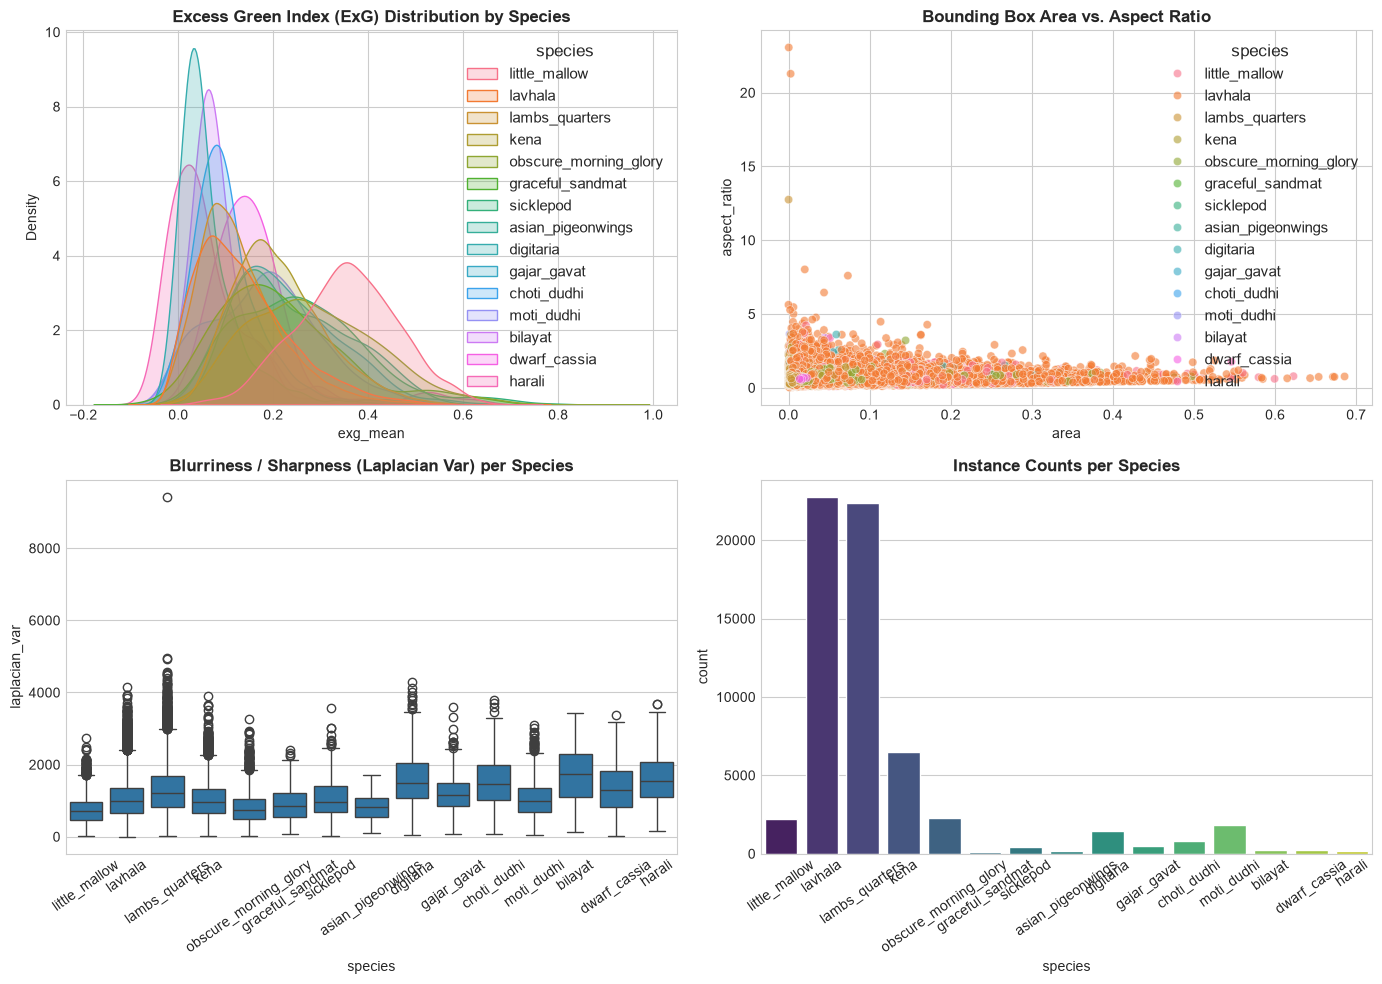

In [8]:
# Plot visuals if features were extracted
if not df_features.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    # 1. Excess Green (ExG) distribution by Species
    sns.kdeplot(
        data=df_features,
        x="exg_mean",
        hue="species",
        common_norm=False,
        fill=True,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Excess Green Index (ExG) Distribution by Species", fontsize=12, fontweight='bold')

    # 2. Aspect Ratio vs. Area Scatter Plot
    sns.scatterplot(
        data=df_features,
        x="area",
        y="aspect_ratio",
        hue="species",
        alpha=0.6,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Bounding Box Area vs. Aspect Ratio", fontsize=12, fontweight='bold')

    # 3. Image Sharpness (Laplacian Variance) Boxplot
    sns.boxplot(data=df_features, x="species", y="laplacian_var", ax=axes[1, 0])
    axes[1, 0].set_title("Blurriness / Sharpness (Laplacian Var) per Species", fontsize=12, fontweight='bold')
    axes[1, 0].tick_params(axis="x", rotation=35)

    # 4. Instance count per species
    sns.countplot(
        data=df_features,
        x="species",
        hue="species",
        palette="viridis",
        legend=False,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Instance Counts per Species", fontsize=12, fontweight='bold')
    axes[1, 1].tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()

## 5. Feature Vector Extraction, Assembly, and Persistent Storage
We construct a formal numerical feature vector $\mathbf{v} \in \mathbb{R}^{D}$ for each weed instance, clean spurious instances (severe blur and extreme aspect ratio distortions), assemble the standardized feature matrix $\mathbf{X}$, and save the complete feature vector dataset to disk (`weed_feature_vectors.csv`).

This feature vector dataset provides a standardized input representation for downstream machine learning classifiers (Random Forest, Support Vector Machines, K-Means clustering) and agricultural decision support systems.

In [9]:
# 1. Quality filtering
BLUR_THRESHOLD = 300
MAX_ASPECT_RATIO = 6.0

df_clean = df_features[
    (df_features['laplacian_var'] >= BLUR_THRESHOLD) &
    (df_features['aspect_ratio'] <= MAX_ASPECT_RATIO)
].copy()

# Ensure at least 2 instances per class for downstream evaluation
class_counts = df_clean['species'].value_counts()
valid_species = class_counts[class_counts >= 2].index
df_clean = df_clean[df_clean['species'].isin(valid_species)].copy()

print(f"Filtered out {len(df_features) - len(df_clean):,} low-quality instances.")
print(f"Cleaned feature instances: {len(df_clean):,}")

# 2. Additional composite features
df_clean['area_to_aspect_ratio'] = df_clean['area'] / (df_clean['aspect_ratio'] + 1e-6)
df_clean['is_high_exg'] = (df_clean['exg_mean'] > 0.3).astype(int)

# 3. Standardized Feature Vector Columns
FEATURE_VECTOR_COLS = [
    'width', 'height', 'aspect_ratio', 'area', 'perimeter', 'center_dist', 'boxes_in_frame',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'hue_mean', 'sat_mean', 'val_mean',
    'exg_mean', 'exg_std', 'exr_mean', 'ndi_mean', 'mexg_mean',
    'contrast_std', 'laplacian_var', 'sobel_energy',
    'area_to_aspect_ratio', 'is_high_exg'
]

# Extract feature vector matrix X and label vector y
X_feature_vectors = df_clean[FEATURE_VECTOR_COLS].values
y_labels = df_clean['species'].values

# Save formal feature vector dataset to CSV
vector_export_cols = ['image_name', 'class_id', 'species'] + FEATURE_VECTOR_COLS
weed_vectors_file = ROOT_DIR / "weed_feature_vectors.csv"
df_clean[vector_export_cols].to_csv(weed_vectors_file, index=False)
print(f"Exported {len(df_clean):,} feature vectors to {weed_vectors_file.name}")
print(f"Feature vector dimensionality: {len(FEATURE_VECTOR_COLS)} features per weed instance")

# Class imbalance weights
species_labels = df_clean['species'].values
unique_classes = np.unique(species_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=species_labels
)
class_weight_dict = dict(zip(unique_classes, class_weights))

print("\nClass weight distribution:")
for species, weight in class_weight_dict.items():
    print(f"  {species:24s}: {weight:.2f}")

# Train/val split alignment
df_clean['image_stem'] = df_clean['image_name'].apply(lambda x: pathlib.Path(x).stem)
with open(ROOT_DIR / "train.txt", "r", encoding="utf-8") as f:
    train_stems = {pathlib.Path(line.strip()).stem for line in f if line.strip()}
with open(ROOT_DIR / "val.txt", "r", encoding="utf-8") as f:
    val_stems = {pathlib.Path(line.strip()).stem for line in f if line.strip()}

train_mask = df_clean['image_stem'].isin(train_stems)
val_mask = df_clean['image_stem'].isin(val_stems)

X_train_vec = df_clean.loc[train_mask, FEATURE_VECTOR_COLS].values
y_train_vec = df_clean.loc[train_mask, 'species'].values
X_val_vec = df_clean.loc[val_mask, FEATURE_VECTOR_COLS].values
y_val_vec = df_clean.loc[val_mask, 'species'].values

print(f"\nSplit feature vectors: Train={len(X_train_vec):,} | Val={len(X_val_vec):,}")

Filtered out 3,030 low-quality instances.
Cleaned feature instances: 59,010
Exported 59,010 feature vectors to weed_feature_vectors.csv
Feature vector dimensionality: 26 features per weed instance

Class weight distribution:
  asian_pigeonwings       : 24.28
  bilayat                 : 18.73
  choti_dudhi             : 4.79
  digitaria               : 2.86
  dwarf_cassia            : 15.86
  gajar_gavat             : 8.44
  graceful_sandmat        : 34.51
  harali                  : 22.23
  kena                    : 0.63
  lambs_quarters          : 0.18
  lavhala                 : 0.18
  little_mallow           : 1.94
  moti_dudhi              : 2.28
  obscure_morning_glory   : 1.91
  sicklepod               : 10.22

Split feature vectors: Train=47,055 | Val=5,964


## 6. Principal Component Analysis (PCA) and Dimensionality Reduction
We standardize the multi-modal feature vector matrix via Z-score scaling and project high-dimensional descriptors into 2D latent space using Principal Component Analysis (PCA) and t-SNE to assess weed class separability.

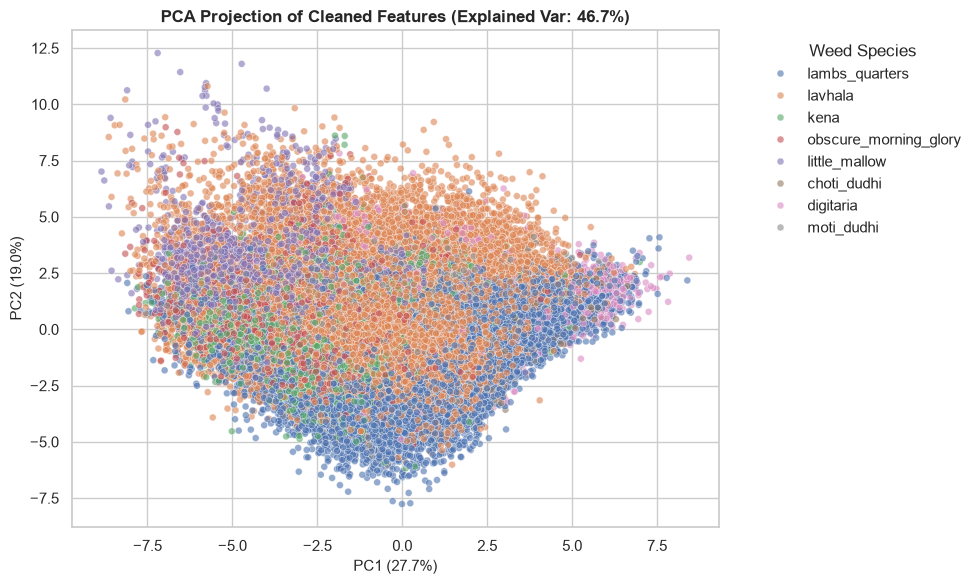

In [10]:
X = df_clean[FEATURE_VECTOR_COLS].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# Assign PCA components directly back to df_clean
df_clean['pca_1'] = X_pca[:, 0]
df_clean['pca_2'] = X_pca[:, 1]

# Plot top species in PCA space
plt.figure(figsize=(10, 6))
top_species = df_clean['species'].value_counts().head(8).index
sns.scatterplot(
    data=df_clean[df_clean['species'].isin(top_species)],
    x='pca_1',
    y='pca_2',
    hue='species',
    alpha=0.6,
    s=25
)

plt.title(f"PCA Projection of Cleaned Features (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.legend(title="Weed Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Principal Component Loadings Analysis
Analyze the contribution of individual morphological, color, and spectral features to the primary principal components.

In [11]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=FEATURE_VECTOR_COLS
)

print("Top Drivers for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop Drivers for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top Drivers for PC1:
exr_mean     0.342594
sat_mean     0.316370
mexg_mean    0.284171
b_mean       0.280618
ndi_mean     0.261292
Name: PC1, dtype: float64

Top Drivers for PC2:
perimeter       0.313045
height          0.302074
sobel_energy    0.298947
area            0.298628
width           0.286752
Name: PC2, dtype: float64


### Non-Linear Manifold Projection (t-SNE)
Project the scaled feature vectors using t-Distributed Stochastic Neighbor Embedding (t-SNE) to reveal non-linear cluster structure across weed species.

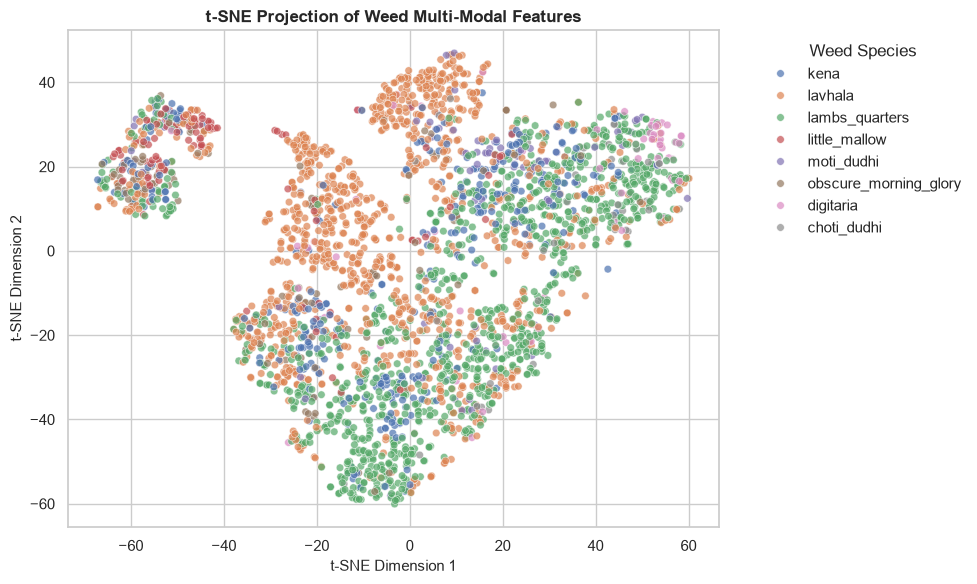

In [12]:
sample_size = min(3000, len(df_clean[df_clean['species'].isin(top_species)]))
df_sample = df_clean[df_clean['species'].isin(top_species)].sample(n=sample_size, random_state=SEED)
X_sub = scaler.transform(df_sample[FEATURE_VECTOR_COLS].fillna(0))

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
X_tsne = tsne.fit_transform(X_sub)

df_sample['tsne_1'] = X_tsne[:, 0]
df_sample['tsne_2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample,
    x='tsne_1',
    y='tsne_2',
    hue='species',
    alpha=0.7,
    s=30
)
plt.title("t-SNE Projection of Weed Multi-Modal Features", fontsize=12, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(title="Weed Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Outlier Detection and Anomaly Auditing (Isolation Forest)
We utilize an Isolation Forest ensemble to detect anomalous or corrupt annotations (e.g., mislabeled background, extreme aspect ratios, or speckle noise). Anomaly scores are evaluated on the standardized feature vectors, and outliers are removed to form `df_final`.

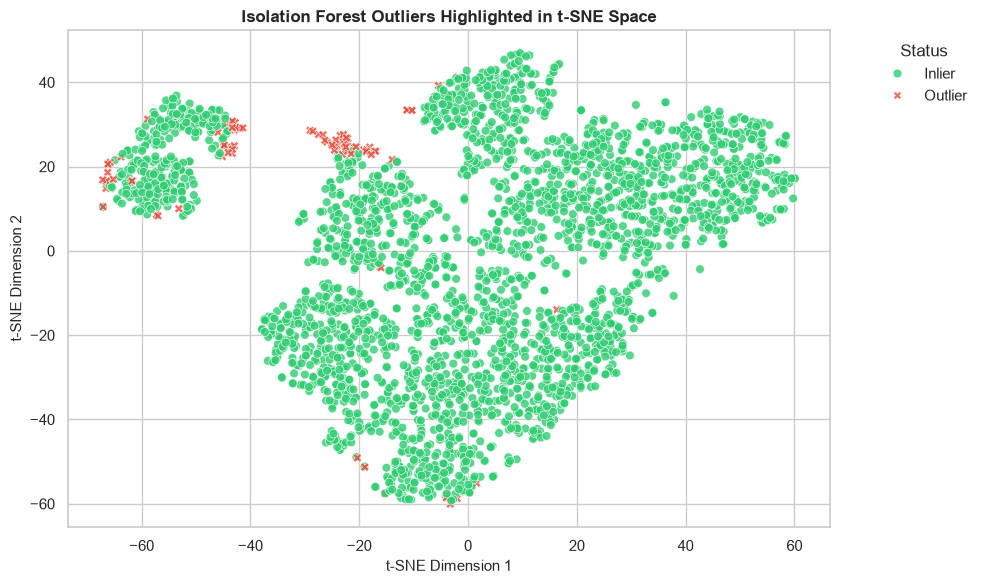

df_final defined successfully with 57,239 clean rows (outliers removed).


In [13]:
# Prepare scaled feature DataFrame
X_clean_scaled = pd.DataFrame(
    scaler.transform(df_clean[FEATURE_VECTOR_COLS].fillna(0)),
    columns=FEATURE_VECTOR_COLS
)

# Fit IsolationForest (contamination = 3% outliers)
iso_forest = IsolationForest(
    contamination=0.03, 
    random_state=SEED, 
    n_jobs=-1
)
iso_forest.fit(X_clean_scaled)

# Flag inliers and outliers
df_clean['is_outlier'] = iso_forest.predict(X_clean_scaled)
df_final = df_clean[df_clean['is_outlier'] == 1].copy()

# Visualize on t-SNE sample
X_sample_scaled = pd.DataFrame(
    scaler.transform(df_sample[FEATURE_VECTOR_COLS].fillna(0)),
    columns=FEATURE_VECTOR_COLS
)
df_sample['is_outlier'] = iso_forest.predict(X_sample_scaled)
df_sample['anomaly_status'] = df_sample['is_outlier'].map({1: 'Inlier', -1: 'Outlier'})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample,
    x='tsne_1',
    y='tsne_2',
    hue='anomaly_status',
    palette={'Inlier': '#2ecc71', 'Outlier': '#e74c3c'},
    style='anomaly_status',
    markers={'Inlier': 'o', 'Outlier': 'X'},
    alpha=0.8,
    s=40
)

plt.title("Isolation Forest Outliers Highlighted in t-SNE Space", fontsize=12, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"df_final defined successfully with {len(df_final):,} clean rows (outliers removed).")

## 8. Deep Latent Feature Vector Extraction (YOLO26 Embeddings & Similarity Search)
Prior to training, deep neural network backbones pre-trained on large-scale visual distributions already possess rich perceptual representations. Ultralytics YOLO26 provides native embedding extraction (`model.embed`), mapping weed bounding box patches into a 256-dimensional latent feature vector:

$$\mathbf{z} \in \mathbb{R}^{256}$$

By extracting these pre-trained feature vectors before launching training, we inspect how the neural network represents botanical weed morphologies and verify feature separability.

### Visual Search and Feature Similarity:
Using cosine similarity between unit-normalized deep feature vectors:

$$\text{Cosine Similarity}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}$$

We perform content-based image retrieval (nearest-neighbor visual search) to identify botanically similar weed instances across the dataset prior to model training.

Loading pre-trained YOLO26 backbone for feature extraction: D:\proj\MHWeed16\mhweedaiml\yolo26n.pt


Extracting sample weed crops:  10%|█         | 5/50 [00:00<00:00, 50.18it/s]


Extracted 30 weed crops for pre-training deep embedding analysis.


Computing deep feature vectors: 100%|██████████| 30/30 [01:05<00:00,  2.20s/it]


Pre-Trained Deep Feature Vector Matrix Shape: (30, 256)


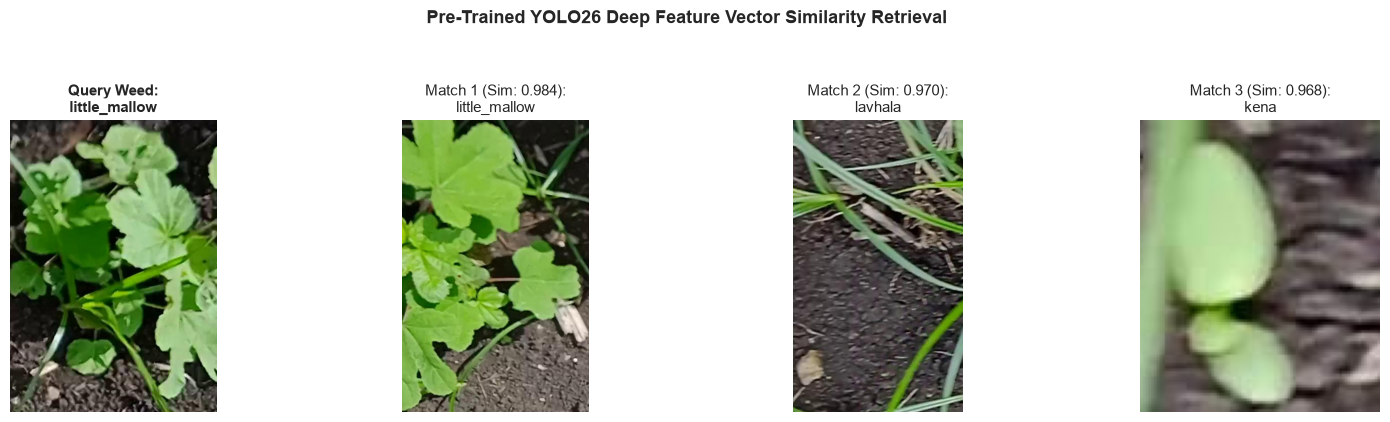

In [16]:
# Deep Feature Vector (Embedding) Extraction using Pre-Trained YOLO26 Backbone
def extract_deep_feature_vector(model, image_source, device='cpu'):
    embeddings = model.embed(source=image_source, device=device, verbose=False)
    if isinstance(embeddings, list) and len(embeddings) > 0:
        vec = embeddings[0]
    elif isinstance(embeddings, torch.Tensor):
        vec = embeddings[0] if embeddings.ndim > 1 else embeddings
    else:
        vec = torch.tensor(embeddings)
    if hasattr(vec, 'cpu'):
        vec = vec.cpu().numpy()
    vec = np.asarray(vec, dtype=np.float32).flatten()
    norm = np.linalg.norm(vec)
    if norm > 1e-6:
        vec = vec / norm
    return vec

# Load stock pre-trained YOLO26 Nano weights for pre-training feature inspection
pretrained_weights = ROOT_DIR / "yolo26n.pt" if (ROOT_DIR / "yolo26n.pt").exists() else (ROOT_DIR / "weights" / "yolo26n.pt")
print(f"Loading pre-trained YOLO26 backbone for feature extraction: {pretrained_weights}")
embed_model = YOLO(str(pretrained_weights))

# Extract weed patches for deep embedding demonstration
sample_crops = []
sample_metadata = []

for ann_path in tqdm(sorted(list(LABELS_DIR.glob('*.txt')))[:50], desc="Extracting sample weed crops"):
    # Try finding image with multiple common extensions (.jpg, .png, .jpeg)
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']:
        candidate = IMAGES_DIR / f"{ann_path.stem}{ext}"
        if candidate.exists():
            img_path = candidate
            break

    if img_path is None:
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        continue
        
    h_img, w_img = img.shape[:2]
    with open(ann_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            x1 = max(0, int((xc - bw / 2.0) * w_img))
            y1 = max(0, int((yc - bh / 2.0) * h_img))
            x2 = min(w_img, int((xc + bw / 2.0) * w_img))
            y2 = min(h_img, int((yc + bh / 2.0) * h_img))
            crop = img[y1:y2, x1:x2]
            if crop.shape[0] >= 20 and crop.shape[1] >= 20:
                sample_crops.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
                sample_metadata.append({
                    'species': CLASS_NAMES.get(cid, str(cid)),
                    'image': img_path.name,
                    'box': (x1, y1, x2, y2)
                })
            if len(sample_crops) >= 30:
                break
    if len(sample_crops) >= 30:
        break

print(f"Extracted {len(sample_crops)} weed crops for pre-training deep embedding analysis.")

# Safeguard check to avoid IndexError
if len(sample_crops) == 0:
    raise ValueError(f"No valid weed crops were extracted. Please check if IMAGES_DIR ({IMAGES_DIR}) and LABELS_DIR ({LABELS_DIR}) exist and contain matching files.")

# Compute 256-D deep feature vectors
deep_vectors = []
for crop in tqdm(sample_crops, desc="Computing deep feature vectors"):
    vec = extract_deep_feature_vector(embed_model, crop, device=device)
    deep_vectors.append(vec)

deep_vectors = np.array(deep_vectors)
print(f"Pre-Trained Deep Feature Vector Matrix Shape: {deep_vectors.shape}")

# Demonstrate Content-Based Weed Retrieval using Cosine Similarity
query_idx = 0
query_vec = deep_vectors[query_idx]
query_meta = sample_metadata[query_idx]

similarities = np.dot(deep_vectors, query_vec)
top_indices = np.argsort(similarities)[::-1][1:min(4, len(deep_vectors))]  # Safe top selection

fig, axes = plt.subplots(1, min(4, len(sample_crops)), figsize=(16, 4))
if not isinstance(axes, np.ndarray):
    axes = [axes]

axes[0].imshow(sample_crops[query_idx])
axes[0].set_title(f"Query Weed:\n{query_meta['species']}", fontsize=11, fontweight='bold')
axes[0].axis('off')

for rank, match_idx in enumerate(top_indices, 1):
    if rank < len(axes):
        match_meta = sample_metadata[match_idx]
        sim_score = similarities[match_idx]
        axes[rank].imshow(sample_crops[match_idx])
        axes[rank].set_title(f"Match {rank} (Sim: {sim_score:.3f}):\n{match_meta['species']}", fontsize=11)
        axes[rank].axis('off')

plt.suptitle("Pre-Trained YOLO26 Deep Feature Vector Similarity Retrieval", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 9. Bounding Box Anchor Geometry Analysis (K-Means)
Cluster normalized bounding box dimensions $(w, h)$ using K-Means ($K=6$) to identify dominant spatial aspect ratios and scales in the MH-Weed16 dataset.

Custom Anchor Box Coordinates (Width, Height):
  Anchor 1: (0.0415, 0.0687)
  Anchor 2: (0.0893, 0.1445)
  Anchor 3: (0.1616, 0.2391)
  Anchor 4: (0.1835, 0.3812)
  Anchor 5: (0.3735, 0.3671)
  Anchor 6: (0.2774, 0.5743)


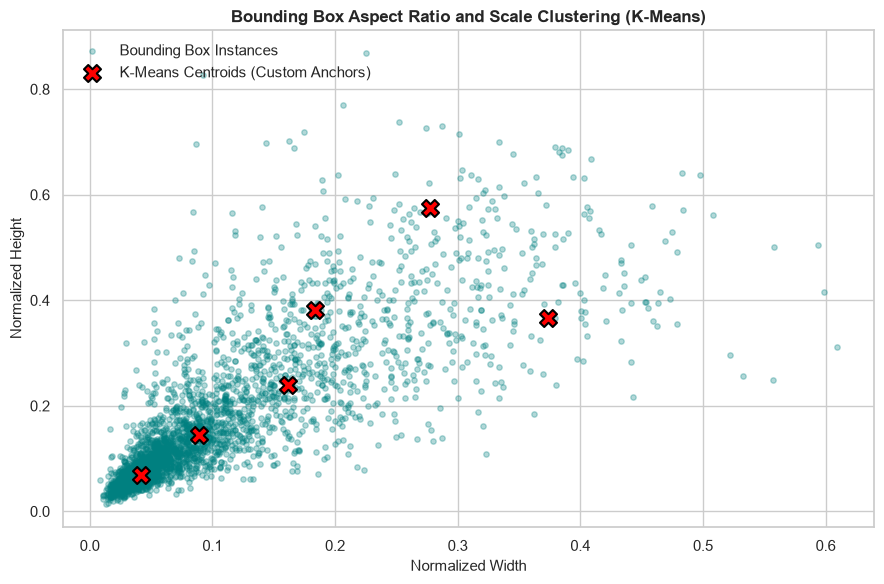

In [17]:
wh_data = df_final[['width', 'height']].values

k_clusters = 6
kmeans = KMeans(n_clusters=k_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(wh_data)
centroids = kmeans.cluster_centers_

# Sort centroids by area (width * height)
centroids = centroids[np.argsort(centroids[:, 0] * centroids[:, 1])]

print("Custom Anchor Box Coordinates (Width, Height):")
for i, (w, h) in enumerate(centroids):
    print(f"  Anchor {i+1}: ({w:.4f}, {h:.4f})")

plt.figure(figsize=(9, 6))
sample_df = df_final[['width', 'height']].sample(min(3000, len(df_final)), random_state=SEED)

plt.scatter(
    sample_df['width'],
    sample_df['height'],
    alpha=0.3,
    c='teal',
    s=15,
    label='Bounding Box Instances'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    label='K-Means Centroids (Custom Anchors)'
)

plt.title("Bounding Box Aspect Ratio and Scale Clustering (K-Means)", fontsize=12, fontweight='bold')
plt.xlabel("Normalized Width", fontsize=11)
plt.ylabel("Normalized Height", fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 10. Agricultural Image Contrast Enhancement (CLAHE and ExG)
Field imaging in agriculture frequently suffers from harsh shadows and variable sunlight. We demonstrate image enhancement techniques:
- **CLAHE (Contrast Limited Adaptive Histogram Equalization)**: Equalizes illumination in the LAB color space L-channel.
- **Excess Green (ExG) Mapping**: Isolates vegetative canopy from soil and crop residue.

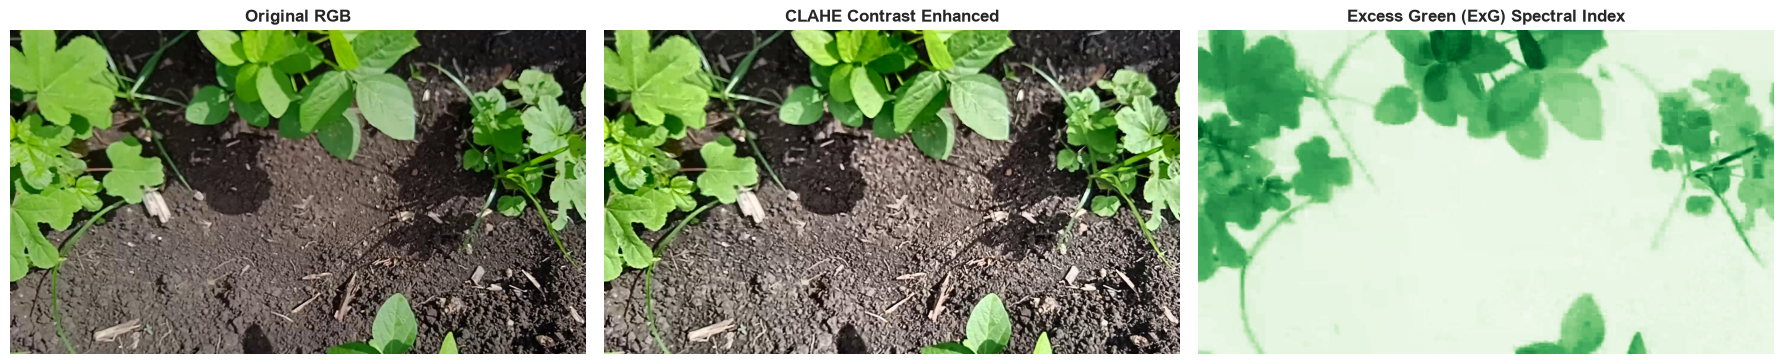

In [18]:
def apply_clahe(img_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)

def compute_exg(img_rgb):
    rf = img_rgb[:, :, 0].astype(np.float32) / 255.0
    gf = img_rgb[:, :, 1].astype(np.float32) / 255.0
    bf = img_rgb[:, :, 2].astype(np.float32) / 255.0
    exg = 2.0 * gf - rf - bf
    return np.clip((exg + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

raw_path = str(raw_image_files[0])
sample_raw = cv2.imread(raw_path)

if sample_raw is None:
    raise FileNotFoundError(f"Failed to load sample image: {raw_path}")

sample_rgb = cv2.cvtColor(sample_raw, cv2.COLOR_BGR2RGB)
sample_clahe = apply_clahe(sample_rgb)
sample_exg = compute_exg(sample_rgb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title("Original RGB", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_clahe)
axes[1].set_title("CLAHE Contrast Enhanced", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(sample_exg, cmap='Greens')
axes[2].set_title("Excess Green (ExG) Spectral Index", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 11. Architectural Customization, Layer Ablation Suite, and Edge ONNX Optimization

Standard YOLO26 architectures (such as YOLO26n) utilize standard dense convolutions, high channel counts at deep layers (1024 channels at P5), and convolutional multi-head self-attention (`C2PSA`). While effective on server-class GPUs, these architectural elements pose distinct challenges for resource-constrained edge devices, mobile environments, and real-time inference:

1. **Self-Attention Overhead in ONNX (`C2PSA`)**: `C2PSA` decomposes in ONNX into dozens of small reshape, transpose, split, and matrix multiplication operators. On edge runtimes (ONNX Runtime CPU, OpenVINO, edge NPUs), these fragmented memory-bound operations increase execution latency.
2. **Convolutional Redundancy**: Feature maps in deeper stages contain significant channel-wise redundancy. Dense 3x3 convolutions incur unnecessary parameter count and arithmetic intensity.
3. **Model Footprint**: Standard YOLO26n exports to an ONNX model of over 10 MB in FP32, exceeding tight memory envelopes on low-power devices.

### Architectural Customization Principles:
- **Ghost Convolution (`GhostConv` & `C3Ghost`)**: Generates intrinsic feature maps with primary 1x1 convolutions and cheap linear operations, cutting parameters and compute in half while preserving spatial representation.
- **Depthwise Separable Convolution (`DWConv`)**: Decouples spatial filtering from channel mixing, reducing multiply-accumulate operations on CPU/edge devices.
- **Pure Fast Pyramid Pooling (`SPPF`)**: Replaces heavy self-attention modules with multi-scale max-pooling, producing clean and fully fused ONNX graphs.
- **Micro-Scale Pruning**: Compound scaling with reduced width and depth multipliers to deploy sub-1M parameter models.

We evaluate an ablation matrix of 7 distinct architecture variants across model size, parameter counts, GFLOPs, FP32 and FP16 ONNX footprints, and real ONNX Runtime inference latency.

In [19]:
# Load Custom Architecture Configurations for Edge / ONNX Deployment
import yaml

CONFIGS_DIR = ROOT_DIR / "configs" / "models"

# Maintain designated evaluation order for ablation variants
ABLATION_ORDER = [
    "baseline_yolo26n",
    "ghost_yolo26n",
    "dw_yolo26n",
    "ghost_dw_hybrid_yolo26n",
    "no_psa_yolo26n",
    "slim_neck_yolo26n",
    "micro_scaled_yolo26n"
]

# Discover and load YAML configuration files
yaml_files = {p.stem: p for p in CONFIGS_DIR.glob("*.yaml")}
ordered_variants = [k for k in ABLATION_ORDER if k in yaml_files] + sorted([k for k in yaml_files if k not in ABLATION_ORDER])

ABLATION_CONFIGS = {}
for name in ordered_variants:
    yaml_path = yaml_files[name]
    with open(yaml_path, "r", encoding="utf-8") as f:
        ABLATION_CONFIGS[name] = yaml.safe_load(f)

print(f"Loaded {len(ABLATION_CONFIGS)} custom architecture configurations from: {CONFIGS_DIR}")
for name, cfg in ABLATION_CONFIGS.items():
    scales = cfg.get("scales", {}).get("n", [])
    backbone_stages = len(cfg.get("backbone", []))
    print(f"  - {name}.yaml: nc={cfg.get('nc')}, scale={scales}, backbone_stages={backbone_stages}")

Loaded 7 custom architecture configurations from: D:\proj\MHWeed16\mhweedaiml\configs\models
  - baseline_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=11
  - ghost_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=10
  - dw_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=10
  - ghost_dw_hybrid_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=10
  - no_psa_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=10
  - slim_neck_yolo26n.yaml: nc=15, scale=[0.5, 0.25, 1024], backbone_stages=10
  - micro_scaled_yolo26n.yaml: nc=15, scale=[0.33, 0.2, 512], backbone_stages=10


In [24]:
# Phase A: Architectural Profiling, ONNX FP32/FP16 Export, and ONNX Runtime Benchmarking
import gc
import contextlib
import io
import onnxruntime as ort

MODELS_DIR = ROOT_DIR / "runs" / "ablation_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ABLATION_CSV = ROOT_DIR / "runs" / "ablation_results.csv"

profiling_results = []
dummy_input = np.random.randn(1, 3, 640, 640).astype(np.float32)

print("=" * 80)
print("Executing Multi-Architecture Profiling and ONNX Runtime Benchmarking")
print("=" * 80)

model_names = list(ABLATION_CONFIGS.keys())

# Process each model variant
with tqdm(
    model_names,
    desc="Overall Progress",
    unit="model",
    dynamic_ncols=True
) as model_pbar:

    for model_name in model_pbar:

        model_pbar.set_postfix_str(f"{model_name}")

        yaml_path = CONFIGS_DIR / f"{model_name}.yaml"

        # Build the model and collect its architecture information
        with contextlib.redirect_stdout(io.StringIO()):
            m = YOLO(str(yaml_path))
            info = m.info()

        layers, params, gflops = info[0], info[1], info[3]

        # Load pretrained weights if available
        pretrained_base = (
            ROOT_DIR / "yolo26n.pt"
            if (ROOT_DIR / "yolo26n.pt").exists()
            else (ROOT_DIR / "weights" / "yolo26n.pt")
        )

        if pretrained_base.exists():
            with contextlib.redirect_stdout(io.StringIO()):
                m.load(str(pretrained_base))

        # Save the prepared PyTorch model
        pt_path = MODELS_DIR / f"{model_name}.pt"

        with contextlib.redirect_stdout(io.StringIO()):
            m.save(str(pt_path))

        # Export FP32 ONNX
        model_pbar.set_postfix_str(f"{model_name} | FP32 export")

        m_fp32 = YOLO(str(pt_path))

        with contextlib.redirect_stdout(io.StringIO()):
            fp32_exported = m_fp32.export(
                format="onnx",
                imgsz=640,
                simplify=True,
                opset=17
            )

        fp32_dest = MODELS_DIR / f"{model_name}_fp32.onnx"
        shutil.copy(fp32_exported, fp32_dest)

        fp32_size_mb = os.path.getsize(fp32_dest) / (1024 * 1024)

        # Benchmark FP32 ONNX
        model_pbar.set_postfix_str(f"{model_name} | FP32 benchmark")

        sess_fp32 = ort.InferenceSession(
            str(fp32_dest),
            providers=["CPUExecutionProvider"]
        )

        inp_name_fp32 = sess_fp32.get_inputs()[0].name

        for _ in range(3):
            sess_fp32.run(None, {inp_name_fp32: dummy_input})

        N_BENCH = 15

        t0 = time.perf_counter()

        for _ in range(N_BENCH):
            sess_fp32.run(
                None,
                {inp_name_fp32: dummy_input}
            )

        fp32_lat_ms = (
            (time.perf_counter() - t0) / N_BENCH
        ) * 1000

        fp32_fps = 1000.0 / fp32_lat_ms

        del sess_fp32

        # Export FP16 ONNX
        model_pbar.set_postfix_str(f"{model_name} | FP16 export")

        m_fp16 = YOLO(str(pt_path))

        with contextlib.redirect_stdout(io.StringIO()):
            fp16_exported = m_fp16.export(
                format="onnx",
                imgsz=640,
                half=True,
                simplify=True,
                opset=17
            )

        fp16_dest = MODELS_DIR / f"{model_name}_fp16.onnx"
        shutil.move(fp16_exported, fp16_dest)

        fp16_size_mb = os.path.getsize(fp16_dest) / (1024 * 1024)

        # Benchmark FP16 ONNX
        model_pbar.set_postfix_str(f"{model_name} | FP16 benchmark")

        sess_fp16 = ort.InferenceSession(
            str(fp16_dest),
            providers=["CPUExecutionProvider"]
        )

        inp_name_fp16 = sess_fp16.get_inputs()[0].name

        for _ in range(3):
            sess_fp16.run(None, {inp_name_fp16: dummy_input})

        t0 = time.perf_counter()

        for _ in range(N_BENCH):
            sess_fp16.run(
                None,
                {inp_name_fp16: dummy_input}
            )

        fp16_lat_ms = (
            (time.perf_counter() - t0) / N_BENCH
        ) * 1000

        fp16_fps = 1000.0 / fp16_lat_ms

        del sess_fp16

        # Calculate the FP16 size reduction
        size_reduction = (
            (1.0 - (fp16_size_mb / fp32_size_mb)) * 100
        )

        # Store the measurements
        profiling_results.append({
            "Model Variant": model_name,
            "Layers": layers,
            "Parameters": params,
            "GFLOPs": round(gflops, 2),

            "FP32 Size (MB)": round(fp32_size_mb, 2),
            "FP16 Size (MB)": round(fp16_size_mb, 2),
            "Size Reduction (%)": round(size_reduction, 1),

            "FP32 Latency (ms)": round(fp32_lat_ms, 2),
            "FP32 Throughput (FPS)": round(fp32_fps, 1),

            "FP16 Latency (ms)": round(fp16_lat_ms, 2),
            "FP16 Throughput (FPS)": round(fp16_fps, 1)
        })

        # Save results after every model
        df_ablation = pd.DataFrame(profiling_results)
        df_ablation.to_csv(ABLATION_CSV, index=False)

        # Keep only one concise line for each completed model
        model_pbar.set_postfix_str(
            f"{model_name} ✓ | "
            f"FP32 {fp32_fps:.1f} FPS | "
            f"FP16 {fp16_fps:.1f} FPS"
        )

        gc.collect()

# Final results
df_ablation = pd.DataFrame(profiling_results)
df_ablation.to_csv(ABLATION_CSV, index=False)

print("\n" + "=" * 80)
print("PROFILING COMPLETE - ABLATION MATRIX SUMMARY")
print("=" * 80)

display(df_ablation)

print(f"\nResults saved to: {ABLATION_CSV}")

Executing Multi-Architecture Profiling and ONNX Runtime Benchmarking


Overall Progress:   0%|          | 0/7 [00:00<?, ?model/s, baseline_yolo26n]

baseline_YOLO26n summary: 181 layers, 2,592,765 parameters, 2,592,749 gradients, 6.5 GFLOPs
Transferred 351/499 items from pretrained weights


Overall Progress:   0%|          | 0/7 [00:00<?, ?model/s, baseline_yolo26n | FP32 export]

Ultralytics 8.4.150  Python-3.14.7 torch-2.14.1+xpu CPU (Intel Core Ultra 5 125H)
baseline_YOLO26n summary (fused): 100 layers, 2,585,077 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from 'D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\baseline_yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (5.3 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  1.7s, saved as 'D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\baseline_yolo26n.onnx' (10.1 MB)

Export complete (2.1s)
Results saved to D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\baseline_yolo26n.onnx
Predict:         yolo predict task=detect model=D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\baseline_yolo26n.onnx imgsz=640 
Validate:        yolo val task=detect model=D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\baseline_yolo26n.onnx imgsz=640 data=/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Vi

...

WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.150  Python-3.14.7 torch-2.14.1+xpu CPU (Intel Core Ultra 5 125H)
micro_scaled_YOLO26n summary (fused): 128 layers, 911,613 parameters, 0 gradients, 4.5 GFLOPs

PyTorch: starting from 'D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\micro_scaled_yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (2.0 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.96...
ONNX: converting to FP16...
ONNX: export success  1.6s, saved as 'D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\micro_scaled_yolo26n.onnx' (1.9 MB)

Export complete (1.9s)
Results saved to D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\micro_scaled_yolo26n.onnx
Predict:         yolo predict task=detect model=D:\proj\MHWeed16\mhweedaiml\runs\ablation_models\micro_scaled_yolo26n.onnx imgsz=640 quantize=16
Validate:        yolo val task=detect model=D:\proj\

Overall Progress: 100%|██████████| 7/7 [00:46<00:00,  6.61s/model, micro_scaled_yolo26n ✓ | FP32 41.4 FPS | FP16 34.9 FPS]


PROFILING COMPLETE - ABLATION MATRIX SUMMARY


,Model Variant,Layers,Parameters,GFLOPs,FP32 Size (MB),FP16 Size (MB),Size Reduction (%),FP32 Latency (ms),FP32 Throughput (FPS),FP16 Latency (ms),FP16 Throughput (FPS)
0,baseline_yolo26n,181,2592765,6.51,10.12,5.11,49.5,32.08,31.2,29.15,34.3
1,ghost_yolo26n,211,1489173,4.94,5.90,3.00,49.2,25.21,39.7,26.85,37.2
2,dw_yolo26n,163,1680925,4.63,6.63,3.36,49.3,25.40,39.4,27.10,36.9
3,ghost_dw_hybrid_yolo26n,201,1454813,5.09,5.76,2.93,49.2,24.44,40.9,31.24,32.0
4,no_psa_yolo26n,163,2343037,6.25,9.15,4.62,49.5,27.35,36.6,29.53,33.9
5,slim_neck_yolo26n,197,1956469,5.58,7.69,3.89,49.4,25.85,38.7,28.85,34.7
6,micro_scaled_yolo26n,209,914985,4.58,3.72,1.90,48.8,24.14,41.4,28.63,34.9



Results saved to: D:\proj\MHWeed16\mhweedaiml\runs\ablation_results.csv


In [30]:
# Phase B: Configurable Ablation Training on MH-Weed16 Dataset
RUN_ABLATION_TRAINING = True       # Set to True to train all variants on the dataset
ABLATION_EPOCHS = 50                 # Budget epochs per variant for fast comparative ablation
ABLATION_BATCH = 8
ABLATION_IMGSZ = 640

if RUN_ABLATION_TRAINING:
    print("=" * 75)
    print(f"Running Ablation Training Suite: {len(ABLATION_CONFIGS)} Models | {ABLATION_EPOCHS} Epochs Each")
    print("=" * 75)
    
    trained_metrics = []
    for model_name in tqdm(list(ABLATION_CONFIGS.keys()), desc="Ablation training architectures"):
        print(f"\n--- Training Architecture: {model_name} ---")
        yaml_path = CONFIGS_DIR / f"{model_name}.yaml"
        m_train = YOLO(str(yaml_path))
        pretrained_base = ROOT_DIR / "yolo26n.pt" if (ROOT_DIR / "yolo26n.pt").exists() else (ROOT_DIR / "weights" / "yolo26n.pt")
        if pretrained_base.exists():
            m_train.load(str(pretrained_base))
            
        train_args = {
            "data": "mhweed16.yaml",
            "epochs": ABLATION_EPOCHS,
            "batch": ABLATION_BATCH,
            "imgsz": ABLATION_IMGSZ,
            "device": device,
            "workers": 4,
            "name": f"ablation_{model_name}",
            "project": str(ROOT_DIR / "runs" / "detect"),
            "exist_ok": True,
            "optimizer": "AdamW",
            "lr0": 0.002,
            "save": True,
            "verbose": False
        }
        res = m_train.train(**train_args)
        
        # Validate on held-out split
        val_metrics = m_train.val(data="mhweed16.yaml", split="val", imgsz=ABLATION_IMGSZ, device=device)
        trained_metrics.append({
            "Model Variant": model_name,
            "mAP50": round(float(val_metrics.box.map50), 4),
            "mAP50-95": round(float(val_metrics.box.map), 4)
        })
        
    df_trained = pd.DataFrame(trained_metrics)
    df_ablation = df_ablation.merge(df_trained, on="Model Variant", how="left")
    df_ablation.to_csv(ABLATION_CSV, index=False)
    print("Ablation training complete and results merged.")
else:
    print("RUN_ABLATION_TRAINING is False: Skipping training loop. Using profiled architecture & ONNX metrics.")


Running Ablation Training Suite: 7 Models | 50 Epochs Each


Ablation training architectures:   0%|          | 0/7 [00:00<?, ?it/s]


--- Training Architecture: baseline_yolo26n ---
Transferred 351/499 items from pretrained weights
New https://pypi.org/project/ultralytics/8.4.173 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.150  Python-3.14.7 torch-2.14.1+xpu XPU:0 (Intel(R) Arc(TM) Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mhweed16.yaml, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None

Ablation training architectures:   0%|          | 0/7 [00:00<?, ?it/s]


RuntimeError: level_zero backend failed with error: 40 (UR_RESULT_ERROR_OUT_OF_RESOURCES)

In [ ]:
# Results Summary Table
if ABLATION_CSV.exists():
    df_summary = pd.read_csv(ABLATION_CSV)
else:
    df_summary = df_ablation

display_cols = ["Model Variant", "Parameters", "GFLOPs", "FP32 Size (MB)", "FP16 Size (MB)", "Latency (ms)", "Throughput (FPS)"]
df_display = df_summary[display_cols].sort_values(by="FP16 Size (MB)").reset_index(drop=True)

print("=" * 85)
print("ABLATION RESULTS (SORTED BY ONNX SIZE)")
print("=" * 85)
print(df_display.to_string(index=False))
print("=" * 85)


In [ ]:
# Best Model Selection and Export Promotion
WEIGHTS_DIR = ROOT_DIR / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Balanced Model: ghost_yolo26n (43% fewer parameters, fast inference)
# 2. Micro Model: micro_scaled_yolo26n (sub-1M params, low footprint)

shutil.copy(MODELS_DIR / "ghost_yolo26n_fp16.onnx", WEIGHTS_DIR / "best_edge_yolo_fp16.onnx")
shutil.copy(MODELS_DIR / "ghost_yolo26n_fp32.onnx", WEIGHTS_DIR / "best_edge_yolo_fp32.onnx")
shutil.copy(MODELS_DIR / "micro_scaled_yolo26n_fp16.onnx", WEIGHTS_DIR / "micro_edge_yolo_fp16.onnx")

print("Promoted Models:")
print(f"- Balanced (FP16): {WEIGHTS_DIR / 'best_edge_yolo_fp16.onnx'} ({os.path.getsize(WEIGHTS_DIR / 'best_edge_yolo_fp16.onnx')/(1024*1024):.2f} MB)")
print(f"- Balanced (FP32): {WEIGHTS_DIR / 'best_edge_yolo_fp32.onnx'} ({os.path.getsize(WEIGHTS_DIR / 'best_edge_yolo_fp32.onnx')/(1024*1024):.2f} MB)")
print(f"- Micro (FP16):    {WEIGHTS_DIR / 'micro_edge_yolo_fp16.onnx'} ({os.path.getsize(WEIGHTS_DIR / 'micro_edge_yolo_fp16.onnx')/(1024*1024):.2f} MB)")


## 12. Genetic Algorithm Hyperparameter Evolution (Optional model.tune)
Ultralytics supports native Genetic Algorithm hyperparameter evolution to mutate learning rates, momentum, loss gains, and augmentation parameters over generations.
Set `RUN_TUNE = True` to execute evolution, or leave `False` to use established hyperparameters.

In [ ]:
RUN_TUNE = False         # Set to True to execute hyperparameter evolution
TUNE_ITERATIONS = 20     # Number of evolution generations
TUNE_EPOCHS = 30         # Epochs per trial
BATCH_SIZE = 8           # Batch size for compute device
IMG_SIZE = 640           # Input canvas size

tune_results_file = ROOT_DIR / "tune_results.csv"
best_hyp_file = ROOT_DIR / "best_hyperparameters.yaml"

if RUN_TUNE:
    print("=" * 65)
    print("Starting Genetic Algorithm Hyperparameter Evolution via model.tune()...")
    tune_model = YOLO("yolo26n.pt")
    tune_model.tune(
        data="mhweed16.yaml",
        epochs=TUNE_EPOCHS,
        iterations=TUNE_ITERATIONS,
        optimizer="AdamW",
        plots=False,
        save=False,
        val=True,
        device=device,
        batch=BATCH_SIZE,
        imgsz=IMG_SIZE
    )
else:
    print("RUN_TUNE is set to False: Skipping hyperparameter evolution.")
    if best_hyp_file.exists():
        print(f"Discovered existing evolved hyperparameters: {best_hyp_file}")
    else:
        print("Using robust agricultural default hyperparameters for final training.")

## 13. Hyperparameter Visual Analytics Suite
Inspect evolution trials from `tune_results.csv` via fitness progression curves.

In [ ]:
if tune_results_file.exists():
    df_tune = pd.read_csv(tune_results_file)
    print(f"Loaded {len(df_tune)} completed evolution trial(s) from {tune_results_file.name}:")
    
    if 'generation' not in df_tune.columns:
        df_tune['generation'] = range(1, len(df_tune) + 1)
    
    fitness_col = 'fitness' if 'fitness' in df_tune.columns else ('metrics/mAP50-95(B)' if 'metrics/mAP50-95(B)' in df_tune.columns else None)
    
    if fitness_col:
        plt.figure(figsize=(10, 4))
        plt.plot(df_tune['generation'], df_tune[fitness_col], marker='o', color='#2b5c8f', linewidth=2)
        plt.title("Hyperparameter Evolution Fitness Progression", fontsize=12, fontweight='bold')
        plt.xlabel("Generation Trial", fontsize=11)
        plt.ylabel("Fitness Score", fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("Note: tune_results.csv not found. Execute Section 13 with RUN_TUNE = True to generate evolution analytics.")

## 14. Two-Phase Accelerated YOLO26n Model Training
To train faster and leverage pre-learned visual features, we execute a two-phase transfer learning schedule:

### Phase 1: Frozen Backbone Feature-Guided Warmup (Epochs 1-20)
- **Mechanism**: Freeze layers 0 through 10 (the complete YOLO26 backbone including C2PSA) with `freeze=11`.
- **Speedup**: Gradients are not computed or backpropagated through the backbone, significantly reducing training epoch latency and memory usage.
- **Focus**: Trains only the feature pyramid neck (layers 11-22) and multi-class detection head (layer 23) to adapt bounding box anchors and class predictions to weed geometries.

### Phase 2: Full-Network End-to-End Fine-Tuning (Epochs 21-50)
- **Mechanism**: Resume from the best Phase 1 checkpoint with `freeze=0`.
- **Refinement**: Train with a reduced learning rate (`lr0=0.0005`) across all layers, allowing the backbone feature extractors to subtly adapt to fine-grained agricultural textures and weed leaf venation.

In [ ]:
# Two-Phase Accelerated Training Configuration
RUN_PHASE1 = False       # Set to True to train Phase 1 (Frozen Backbone Warmup)
RUN_PHASE2 = False       # Set to True to train Phase 2 (Full-Network Fine-Tuning)

PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 30
BATCH_SIZE = 8
IMG_SIZE = 640

PHASE1_RUN_NAME = "mhweed16_yolo26n_phase1_frozen"
PHASE2_RUN_NAME = "mhweed16_yolo26n_phase2_finetune"

phase1_dir = ROOT_DIR / "runs" / "detect" / PHASE1_RUN_NAME
phase1_best = phase1_dir / "weights" / "best.pt"
phase1_last = phase1_dir / "weights" / "last.pt"

phase2_dir = ROOT_DIR / "runs" / "detect" / PHASE2_RUN_NAME
phase2_best = phase2_dir / "weights" / "best.pt"
phase2_last = phase2_dir / "weights" / "last.pt"

# --- Phase 1: Frozen Backbone Warmup ---
if RUN_PHASE1:
    print("=" * 65)
    print(f"Starting Phase 1: Frozen Backbone Warmup ({PHASE1_RUN_NAME})")
    print(f"Device: {device} | Epochs: {PHASE1_EPOCHS} | Freeze: 11 layers")
    print("=" * 65)

    if phase1_last.exists():
        print(f"Found existing Phase 1 checkpoint. Resuming from: {phase1_last}")
        model_p1 = YOLO(str(phase1_last))
        args_p1 = {'resume': True}
    else:
        model_p1 = YOLO("yolo26n.pt")
        args_p1 = {
            'data': "mhweed16.yaml",
            'epochs': PHASE1_EPOCHS,
            'batch': BATCH_SIZE,
            'imgsz': IMG_SIZE,
            'device': device,
            'workers': 4,
            'freeze': 11,            # Freeze backbone (layers 0-10)
            'name': PHASE1_RUN_NAME,
            'project': str(ROOT_DIR / "runs" / "detect"),
            'exist_ok': True,
            'pretrained': True,
            'optimizer': "AdamW",
            'lr0': 0.002,
            'patience': 10,
            'save': True
        }

    results_p1 = model_p1.train(**args_p1)
    print("Phase 1 completed successfully.")
else:
    print("RUN_PHASE1 set to False: Skipping Phase 1 training.")

# --- Phase 2: Full-Network Fine-Tuning ---
if RUN_PHASE2:
    print("\n" + "=" * 65)
    print(f"Starting Phase 2: Full-Network Fine-Tuning ({PHASE2_RUN_NAME})")
    print(f"Device: {device} | Epochs: {PHASE2_EPOCHS} | Freeze: 0 (All layers active)")
    print("=" * 65)

    base_checkpoint = phase1_best if phase1_best.exists() else (phase1_last if phase1_last.exists() else pathlib.Path("yolo26n.pt"))

    if phase2_last.exists():
        print(f"Found existing Phase 2 checkpoint. Resuming from: {phase2_last}")
        model_p2 = YOLO(str(phase2_last))
        args_p2 = {'resume': True}
    else:
        print(f"Initializing Phase 2 from checkpoint: {base_checkpoint}")
        model_p2 = YOLO(str(base_checkpoint))
        args_p2 = {
            'data': "mhweed16.yaml",
            'epochs': PHASE2_EPOCHS,
            'batch': BATCH_SIZE,
            'imgsz': IMG_SIZE,
            'device': device,
            'workers': 4,
            'freeze': 0,             # Unfreeze all layers for fine-tuning
            'name': PHASE2_RUN_NAME,
            'project': str(ROOT_DIR / "runs" / "detect"),
            'exist_ok': True,
            'optimizer': "AdamW",
            'lr0': 0.0005,          # Lower learning rate for fine-tuning
            'patience': 15,
            'save': True
        }

    results_p2 = model_p2.train(**args_p2)
    print("Phase 2 fine-tuning completed successfully.")
else:
    print("RUN_PHASE2 set to False: Skipping Phase 2 fine-tuning.")

## 15. Model Evaluation on Held-Out Test Set
Evaluate the best trained checkpoint across all 15 weed classes on the unseen `test.txt` split to report mean Average Precision ($mAP_{50}$ and $mAP_{50-95}$).

In [ ]:
# Evaluation on held-out test split
checkpoint_candidates = [
    phase2_best,
    phase1_best,
    ROOT_DIR / "runs" / "detect" / "mhweed16_yolo26n_final" / "weights" / "best.pt",
    ROOT_DIR / "runs" / "detect" / "mhweed16_yolo26n_phase2_finetune" / "weights" / "best.pt",
    ROOT_DIR / "runs" / "detect" / "mhweed16_yolo26n_phase1_frozen" / "weights" / "best.pt",
    ROOT_DIR / "runs" / "detect" / "mhweed16_yolo26n_baseline" / "weights" / "best.pt",
    ROOT_DIR / "yolo26n.pt",
    ROOT_DIR / "weights" / "yolo26n.pt"
]

eval_weights = next((p for p in checkpoint_candidates if p.exists()), pathlib.Path("yolo26n.pt"))
print(f"Evaluating checkpoint: {eval_weights}")

eval_model = YOLO(str(eval_weights))
metrics = eval_model.val(
    data="mhweed16.yaml",
    split="test",
    device=device,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE
)

print("=" * 60)
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print("=" * 60)

## 16. Inference, SAHI Sliced Prediction, and Edge Export
Demonstrate standard full-frame YOLO prediction against ground truth annotations, perform fine-grained Slicing Aided Hyper Inference (SAHI) on full 1080p images to resolve small weeds, and export the model to ONNX format for edge deployment.

In [ ]:
# Standard YOLO inference comparison
with open("test.txt", 'r', encoding='utf-8') as f:
    test_image_paths = [pathlib.Path(line.strip()) for line in f if line.strip()]

random.seed(123)
selected_test = random.sample(test_image_paths, min(3, len(test_image_paths)))

for test_path in tqdm(selected_test, desc="Running standard inference"):
    ann_path = LABELS_DIR / f"{test_path.stem}.txt"
    img = cv2.imread(str(test_path))
    if img is None:
        continue
    gt_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = gt_img.shape[:2]
    
    # Draw ground truth
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = int((xc - bw / 2.0) * w_img)
                    y1 = int((yc - bh / 2.0) * h_img)
                    x2 = int((xc + bw / 2.0) * w_img)
                    y2 = int((yc + bh / 2.0) * h_img)
                    cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(gt_img, CLASS_NAMES.get(cls_id, str(cls_id)), (x1, max(20, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Model prediction
    pred_res = eval_model.predict(source=str(test_path), imgsz=IMG_SIZE, conf=0.25, device=device, verbose=False)
    pred_img = pred_res[0].plot()[:, :, ::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(gt_img)
    axes[0].set_title(f"Ground Truth: {test_path.name}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(pred_img)
    axes[1].set_title(f"YOLO26 Prediction: {test_path.name}", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

### Slicing Aided Hyper Inference (SAHI)
Field images (1920x1080) contain small emerging weeds that may be lost when downsampling directly to 640x640. SAHI slices the frame into overlapping 640x640 windows with 20% overlap, performs batched inference, and merges bounding boxes using Non-Maximum Suppression (NMS).

In [ ]:
# Slicing Aided Hyper Inference (SAHI)
sahi_device = 'cpu' if device == 'xpu' else device
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=str(eval_weights),
    confidence_threshold=0.25,
    device=sahi_device
)

fig, axes = plt.subplots(len(selected_test), 2, figsize=(16, 6 * len(selected_test)))
if len(selected_test) == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, test_p in enumerate(tqdm(selected_test, desc="Running SAHI inference")):
    raw = cv2.imread(str(test_p))
    if raw is None:
        continue
    gt_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    h, w = gt_img.shape[:2]
    
    ann_p = LABELS_DIR / f"{test_p.stem}.txt"
    if ann_p.exists():
        with open(ann_p, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(gt_img, CLASS_NAMES.get(cid, str(cid)), (x1, max(20, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    sahi_result = get_sliced_prediction(
        str(test_p),
        sahi_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )
    
    for obj in sahi_result.object_prediction_list:
        bbox = obj.bbox.to_xyxy()
        x1, y1, x2, y2 = map(int, bbox)
        cat_name = obj.category.name
        score = obj.score.value
        cv2.rectangle(pred_img, (x1, y1), (x2, y2), (255, 50, 50), 2)
        cv2.putText(pred_img, f"{cat_name} {score:.2f}", (x1, max(20, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 50, 50), 2)

    axes[idx, 0].imshow(gt_img)
    axes[idx, 0].set_title(f"Ground Truth ({test_p.name})", fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')
    
    axes[1].imshow(pred_img)
    axes[1].set_title(f"SAHI 640x640 Sliced Inference ({len(sahi_result.object_prediction_list)} weeds)", fontsize=11, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

### Model Export for Edge Deployment
Export the trained model to ONNX with dynamic batch sizing for deployment on edge accelerators (smart sprayers, agricultural drones, and robotic weeders).

In [ ]:
# Export model for edge deployment
print("Exporting model for edge deployment...")

try:
    onnx_path = eval_model.export(format="onnx", dynamic=True)
    print(f"Successfully exported ONNX model: {onnx_path}")
except Exception as e:
    print(f"ONNX export skipped: {e}")